# Optimization

This notebook studies how derivatives help locate maximum and minimum values, why optimization matters in machine learning, and how derivative information guides iterative search methods.

## Video 1 — Derivatives and optimization

**Optimization** means finding an input where a function reaches a maximum or minimum value.

In machine learning, a model is evaluated using an **error**, **loss**, or **objective** function. This function assigns a number that measures how poorly the model fits the chosen goal. Training often means adjusting the model's parameters to make that number as small as possible.

Derivatives help because they describe which direction makes the objective increase or decrease.

### Searching for the coldest place on a sauna bench

Imagine sitting on a sauna bench with a thermometer:

1. At the initial position, the temperature is $85$ degrees Celsius.
2. Moving left produces a reading of $90$ degrees Celsius, so that direction is hotter.
3. Moving right produces a reading of $80$ degrees Celsius, so that direction is colder.
4. Continuing toward lower readings eventually reaches a position where moving either way makes the temperature rise.

That final position is a minimum of the temperature function: locally, no nearby position is colder.

### What the derivative says

Let $T(x)$ be the temperature at position $x$ along the bench.

- If $T'(x)<0$, the graph slopes downward as $x$ increases, so moving right decreases the temperature.
- If $T'(x)>0$, the graph slopes upward as $x$ increases, so moving left decreases the temperature.
- At a smooth interior minimum, $T'(x)=0$ because the tangent is horizontal.

Thus, points satisfying

$$
T'(x)=0
$$

are **candidates** for maxima or minima. A zero derivative alone does not prove that a point is an optimum.

### Simple and more complicated temperature curves

The left plot reconstructs the lecture's $85$, $90$, and $80$ degree readings using schematic bench positions. The curve and its minimum temperature are illustrative because their exact values are not supplied in the transcript.

The right plot is also schematic. It shows why a complicated function may have several zero-derivative candidates that must be classified.

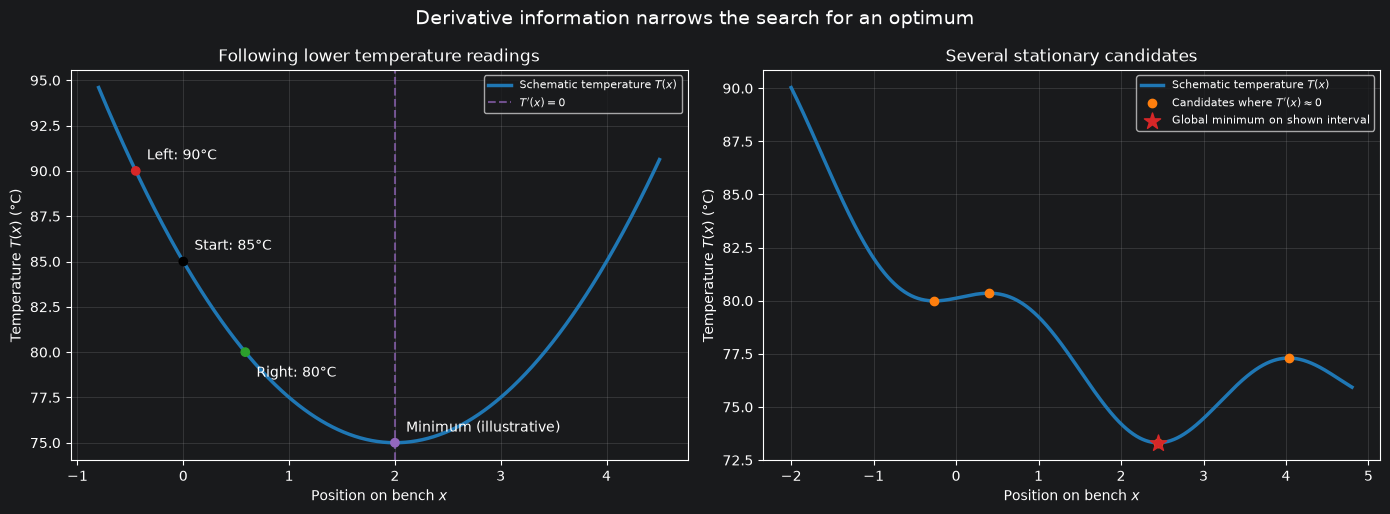

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

simple_positions: np.ndarray = np.linspace(-0.8, 4.5, 500)
simple_temperatures: np.ndarray = 75.0 + 2.5 * (simple_positions - 2.0) ** 2
initial_position: float = 0.0
left_trial_position: float = 2.0 - float(np.sqrt(6.0))
right_trial_position: float = 2.0 - float(np.sqrt(2.0))
minimum_position: float = 2.0

complex_positions: np.ndarray = np.linspace(-2.0, 4.8, 1000)
complex_temperatures: np.ndarray = (
    75.0 + 0.5 * (complex_positions - 3.2) ** 2 + 2.0 * np.sin(2.0 * complex_positions)
)
complex_derivatives: np.ndarray = complex_positions - 3.2 + 4.0 * np.cos(2.0 * complex_positions)
critical_indices: np.ndarray = np.flatnonzero(
    np.sign(complex_derivatives[:-1]) != np.sign(complex_derivatives[1:])
)
global_minimum_index: int = int(np.argmin(complex_temperatures))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
axes[0].plot(simple_positions, simple_temperatures, color="tab:blue", linewidth=2.5,
             label="Schematic temperature $T(x)$")
axes[0].scatter(
    [initial_position, left_trial_position, right_trial_position, minimum_position],
    [85.0, 90.0, 80.0, 75.0],
    color=["black", "tab:red", "tab:green", "tab:purple"],
    zorder=3,
)
axes[0].annotate("Start: $85°$C", (initial_position, 85.0), xytext=(8, 8),
                 textcoords="offset points")
axes[0].annotate("Left: $90°$C", (left_trial_position, 90.0), xytext=(8, 8),
                 textcoords="offset points")
axes[0].annotate("Right: $80°$C", (right_trial_position, 80.0), xytext=(8, -18),
                 textcoords="offset points")
axes[0].annotate("Minimum (illustrative)", (minimum_position, 75.0), xytext=(8, 8),
                 textcoords="offset points")
axes[0].axvline(minimum_position, color="tab:purple", linestyle="--", alpha=0.7,
                label="$T'(x)=0$")
axes[0].set(title="Following lower temperature readings", xlabel="Position on bench $x$",
            ylabel="Temperature $T(x)$ (°C)")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].plot(complex_positions, complex_temperatures, color="tab:blue", linewidth=2.5,
             label="Schematic temperature $T(x)$")
axes[1].scatter(complex_positions[critical_indices], complex_temperatures[critical_indices],
                color="tab:orange", zorder=3, label="Candidates where $T'(x)\\approx0$")
axes[1].scatter([complex_positions[global_minimum_index]],
                [complex_temperatures[global_minimum_index]], color="tab:red", marker="*",
                s=150, zorder=4, label="Global minimum on shown interval")
axes[1].set(title="Several stationary candidates", xlabel="Position on bench $x$",
            ylabel="Temperature $T(x)$ (°C)")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

fig.suptitle("Derivative information narrows the search for an optimum", fontsize=14)
fig.tight_layout()
plt.show()

### Local and global minima

A **local minimum** is a point whose function value is no larger than the values at nearby points. A **global minimum** is a point whose function value is no larger than the value at every other point in the domain.

A complicated function can contain several stationary points where

$$
f'(x)=0.
$$

They are candidates, not guaranteed minima. A stationary point could be:

- a local minimum;
- a local maximum;
- neither, such as a flat point where the function continues increasing.

To find the global minimum, the candidates must be evaluated and compared with every other type of candidate required by the domain.

### The condition behind the zero-slope rule

The precise result is:

> If $f$ is differentiable at an **interior** point $x^*$ and has a local maximum or minimum there, then $f'(x^*)=0$.

The conditions matter. An optimum can also occur:

- at an endpoint of a restricted interval;
- at a point where the derivative does not exist, such as the corner of $|x|$;
- at one of several points where the derivative is zero.

Therefore, solving $f'(x)=0$ finds important candidates, but it does not complete every optimization problem by itself.

### Takeaway

Derivatives turn optimization into a more focused search:

$$
\boxed{f'(x)=0}
$$

identifies stationary candidates for smooth interior maxima and minima. The derivative's sign also provides direction:

- $f'(x)<0$: increasing $x$ locally decreases $f$;
- $f'(x)>0$: decreasing $x$ locally decreases $f$;
- $f'(x)=0$: inspect and classify the point.

In machine learning, this idea is used to search for parameter values that minimize a chosen loss or objective function.